In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
def plot_data(file, skip, teff_min, teff_max, per_min, per_max):
    df_combined = pd.DataFrame()

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_orbper'}, inplace=True)
    #print(df.columns)

    df = df.dropna(subset=['st_teff', 'pl_orbper'])
    df = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df = df[(df['pl_orbper'] < per_max) & (df['pl_orbper'] > per_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    df_combined = pd.concat([df_combined, df], ignore_index=True)

    if 'pl_name' in df.columns:
        for i, txt in enumerate(df['pl_orbper']):
            plt.annotate(txt, (df['pl_orbper'].iloc[i], df['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    data_for_plot_1 = df_combined[['pl_orbper', 'st_teff']]

    file_1_len = len(df_combined)

    avg_pl_orbper = df_combined['pl_orbper'].mean()
    median_pl_orbper = df_combined['pl_orbper'].median()
    #plt.figure(figsize=(10, 6))
    plt.hist(data_for_plot_1['pl_orbper'], bins=50, alpha=0.5, label=str(f'{file} {teff_min}-{teff_max}K'))
    plt.axvline(avg_pl_orbper, color='r', linestyle='dashed', linewidth=1, label=f'Mean period: {avg_pl_orbper:.2f}')
    plt.axvline(median_pl_orbper, color='k', linestyle='dashed', linewidth=1, label=f'Median period: {median_pl_orbper:.2f}')
    plt.title('Histogram of Planetary Orbital Period (pl_orbper)')
    plt.xlabel('Planetary Orbital Period (days)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

    return teff_min, teff_max, per_min, per_max, file_1_len, avg_pl_orbper, median_pl_orbper


KeyError: 'pl_name'
File: TOI_Mar2025.csv
Number of planets: 33
Teff range: 3000 - 3200 K
Period range: 1 - 50 days

Average Planetary Orbital Period: 6.969716754545454
Median Planetary Orbital Period: 3.4950422


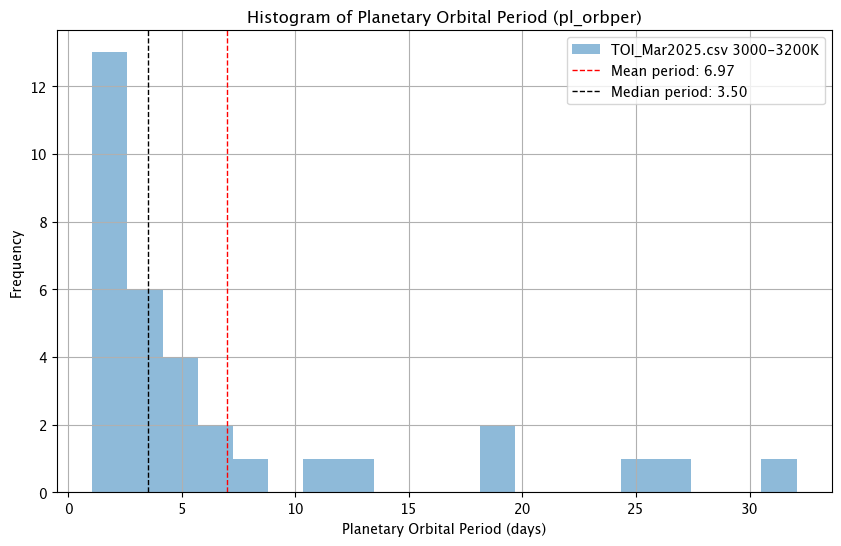

In [14]:
file1 = 'TOI_Mar2025.csv'
skip1 = 71
teff_min1 = 3000
teff_max1 = 3200
per_min1 = 1
per_max1 = 50

teff_min1, teff_max1, per_min1, per_max1, file_1_len, avg_pl_orbper, median_pl_orbper = plot_data(file1, skip1, teff_min1, teff_max1, per_min1, per_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nPeriod range: {per_min1} - {per_max1} days\n")
print(f"Average Planetary Orbital Period: {avg_pl_orbper}")
print(f"Median Planetary Orbital Period: {median_pl_orbper}")

KeyError: 'pl_name'
File: TOI_Mar2025.csv
Number of planets: 79
Teff range: 3200 - 3400 K
Period range: 1 - 50 days

Average Planetary Orbital Period: 6.246373279746835
Median Planetary Orbital Period: 3.7924221
KeyError: 'pl_name'
File: TOI_Mar2025.csv
Number of planets: 33
Teff range: 3000 - 3200 K
Period range: 1 - 50 days

Average Planetary Orbital Period: 6.969716754545454
Median Planetary Orbital Period: 3.4950422


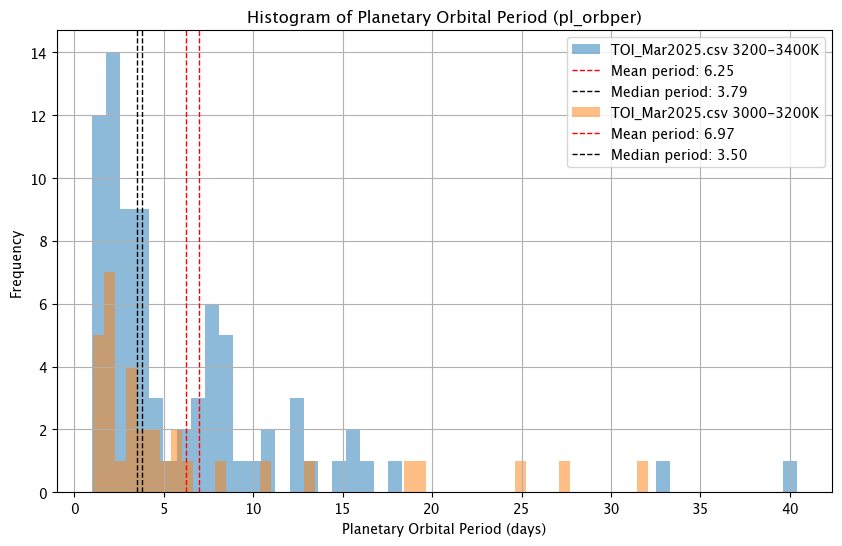

In [21]:
plt.figure(figsize=(10, 6))

file1 = 'TOI_Mar2025.csv'
skip1 = 71
teff_min1 = 3200
teff_max1 = 3400
per_min1 = 1
per_max1 = 50

teff_min1, teff_max1, per_min1, per_max1, file_1_len, avg_pl_orbper, median_pl_orbper = plot_data(file1, skip1, teff_min1, teff_max1, per_min1, per_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nPeriod range: {per_min1} - {per_max1} days\n")
print(f"Average Planetary Orbital Period: {avg_pl_orbper}")
print(f"Median Planetary Orbital Period: {median_pl_orbper}")

file1 = 'TOI_Mar2025.csv'
skip1 = 71
teff_min1 = 3000
teff_max1 = 3200
per_min1 = 1
per_max1 = 50

teff_min1, teff_max1, per_min1, per_max1, file_1_len, avg_pl_orbper, median_pl_orbper = plot_data(file1, skip1, teff_min1, teff_max1, per_min1, per_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nPeriod range: {per_min1} - {per_max1} days\n")
print(f"Average Planetary Orbital Period: {avg_pl_orbper}")
print(f"Median Planetary Orbital Period: {median_pl_orbper}")

KeyError: 'pl_name'
File: TOI_Mar2025.csv
Number of planets: 120
Teff range: 3400 - 3600 K
Period range: 1 - 50 days

Average Planetary Orbital Period: 6.680821103333334
Median Planetary Orbital Period: 4.12153605


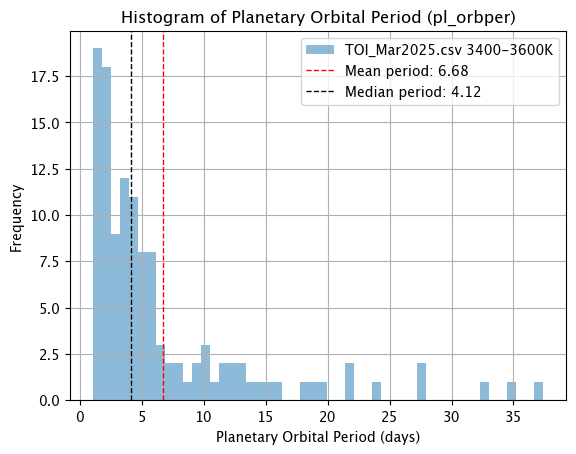

In [22]:
file1 = 'TOI_Mar2025.csv'
skip1 = 71
teff_min1 = 3400
teff_max1 = 3600
per_min1 = 1
per_max1 = 50

teff_min1, teff_max1, per_min1, per_max1, file_1_len, avg_pl_orbper, median_pl_orbper = plot_data(file1, skip1, teff_min1, teff_max1, per_min1, per_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nPeriod range: {per_min1} - {per_max1} days\n")
print(f"Average Planetary Orbital Period: {avg_pl_orbper}")
print(f"Median Planetary Orbital Period: {median_pl_orbper}")

KeyError: 'pl_name'
File: TOI_Mar2025.csv
Number of planets: 110
Teff range: 3600 - 3800 K
Period range: 1 - 50 days

Average Planetary Orbital Period: 6.834411759090911
Median Planetary Orbital Period: 4.4864275


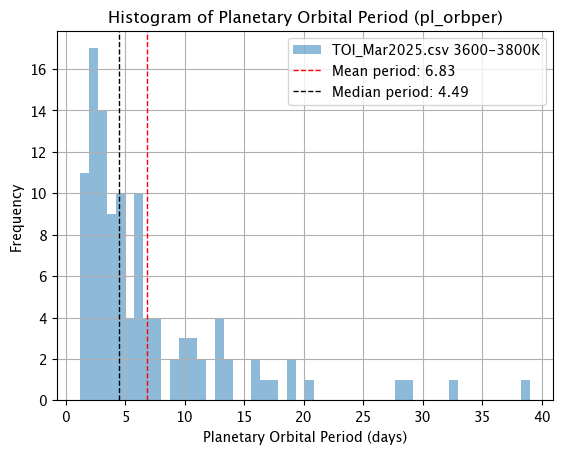

In [23]:
file1 = 'TOI_Mar2025.csv'
skip1 = 71
teff_min1 = 3600
teff_max1 = 3800
per_min1 = 1
per_max1 = 50

teff_min1, teff_max1, per_min1, per_max1, file_1_len, avg_pl_orbper, median_pl_orbper = plot_data(file1, skip1, teff_min1, teff_max1, per_min1, per_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nPeriod range: {per_min1} - {per_max1} days\n")
print(f"Average Planetary Orbital Period: {avg_pl_orbper}")
print(f"Median Planetary Orbital Period: {median_pl_orbper}")